In [149]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xgboost as xgb

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.patches import Rectangle

In [150]:
# =============================================================================
# Benchmark Comparison
# =============================================================================

file_names = []

example = r'01_analysis_RealTest_Karlsruhe_200kPa' ## needs user interaction
path_user = r'C:\Users\haris\Documents\GitHub\MLpFEM\data\\'
path = path_user + example + "\\02_rawdata_interpolated\\"

file = r"Triaxial test_q_eps1.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_opt = df_data_triax.iloc[0,:]  
q_opt = df_data_triax.iloc[1,:] 

file = r"Triaxial test_epsvol.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_opt = df_data_triax.iloc[0,:] 
eps_vol_opt  = df_data_triax.iloc[1,:] 

file = r"Triaxial test_path.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
p_opt_path = df_data_triax.iloc[0,:] 
q_opt_path  = df_data_triax.iloc[1,:] 

file = r"Oedometer.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_oed_opt = df_data_triax.iloc[0,:]  
sig_1_opt  = df_data_triax.iloc[1,:] 


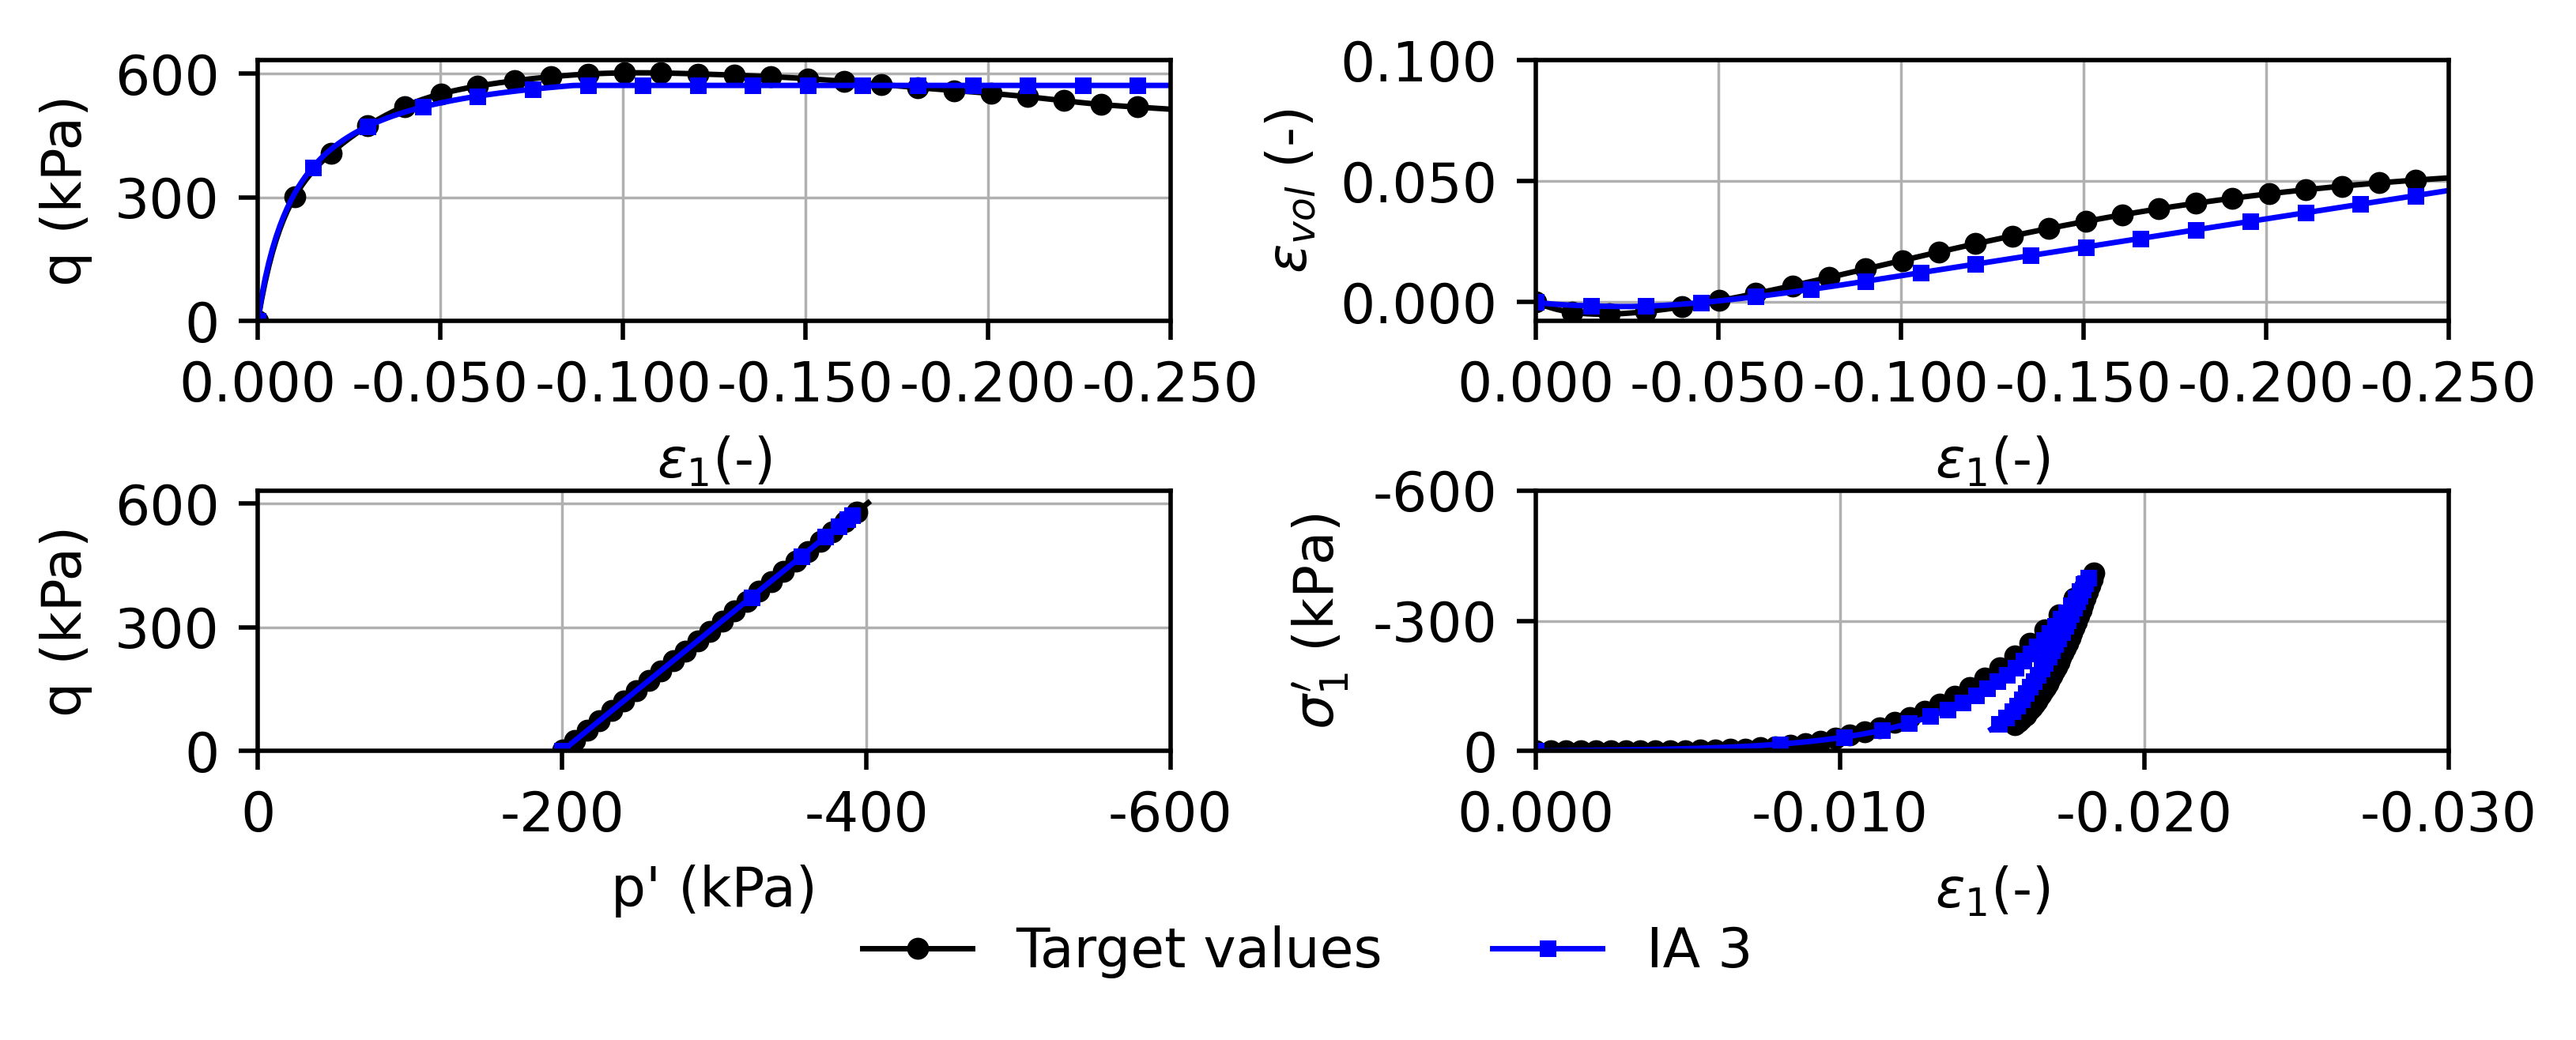

In [151]:
examples = [example]
folders = ['02_rawdata_interpolated\\', '13_IA3_final\\']
labels = ['Target values', 'IA 3']

colors = ['k', 'b', 'orange', 'red', 'orange', 'green', 'black', 'yellow', 'pink', 'brown', 'cyan', 'magenta']
markers = ['o', 's', 'd', 'd', '+', 'x', 'x', 'x', 'x', 'x', 'x', 'x']

markersizes = [3, 2, 2, 0,0, 0, 0, 0, 0, 0, 0, 0]
markeverys= [10,15,25, 25, 25, 25, 25, 25, 25, 25, 25, 25]

cm = 1/2.54  # centimeters in inches

for k, example in enumerate(examples):
    fig, axs = plt.subplots(2, 2, figsize=(16*cm, 6*cm), dpi=500)

    for i, folder in enumerate(folders):
        for j, file_name in enumerate(file_names):
            df_data_syn = pd.read_csv(path_user + example + "\\" + folder + file_name, sep="\t", header=None)
            x = df_data_syn.iloc[:, 0]
            y = df_data_syn.iloc[:, 1]
    
            x = np.array(x)
            y = np.array(y)
    
            axs[j//2, j%2].plot(x, y, marker = markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i])
            axs[j//2, j%2].grid(True, linewidth=0.5)
            axs[j//2, j%2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[j//2, j%2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            
            axs[1, 0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[1, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[0, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[1, 1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    
            # Invert x-axis for all plots
            axs[j//2, j%2].invert_xaxis()

            # Invert y-axis for the last plot
            if j == len(file_names) - 1:
                axs[j//2, j%2].invert_yaxis()
    
            axs[j//2, j%2].set_xlabel('$\epsilon_{1}$(-)')
            axs[1, 0].set_xlabel("p' (kPa)")
            axs[0, 0].set_ylabel('q (kPa)')
            axs[1, 0].set_ylabel('q (kPa)')
            axs[0, 1].set_ylabel('$\epsilon_{vol}$ (-)')
            axs[1, 1].set_ylabel("$\sigma_{1}'$ (kPa)")

            if j == 3: # oedoemeter
                default_ticks = axs[1, 0].get_xticks()
                axs[1, 0].set_yticks([0,300,600])
                axs[1, 0].set_ylim(0)
                axs[1, 0].set_xlim(xmin = 0, xmax = -600)
            if j == 0: # stress strain
                axs[0, 0].set_xlim(0, -0.25)
                axs[0, 0].set_yticks([0,300,600])
                axs[0, 0].set_ylim(0)
            if j == 1: # volumetric behaviour
                axs[0, 1].set_yticks([0, 0.05,0.10])
                axs[0, 1].set_xlim(0,-0.25)

            if j == 2: # stress path
                axs[1, 1].set_ylim(-600,0)
                axs[1, 1].set_yticks([0,-300,-600])
                axs[1, 1].set_xlim(-0.030,0)

                
    # Create legend outside the loop
    plt.legend(loc='upper center', bbox_to_anchor=(-.25, -.48), frameon=False, ncol=4)
    plt.subplots_adjust(left=0.08, right=0.96, bottom=0.24, top=0.98, wspace=0.40, hspace=0.65)

    plt.savefig(r"../graphics/"+"SyntheticData_"+f"{example}"+".png", dpi=1000)

In [152]:
#stack the data together
X_triax = np.hstack((q_opt, eps_y_opt, eps_vol_opt, eps_y_opt, q_opt_path, p_opt_path))
X_triax = np.reshape(X_triax, (1, -1))
X_triax = pd.DataFrame(X_triax)

X_oedo = np.hstack((sig_1_opt, eps_y_oed_opt))
X_oedo = np.reshape(X_oedo, (1, -1))
X_oedo = pd.DataFrame(X_oedo)

In [153]:
print("Triaxial test:", len(X_triax.columns))
print("Oedometer test:", len(X_oedo.columns))

Triaxial test: 1500
Oedometer test: 1500


In [154]:
X = pd.concat([X_triax, X_oedo], ignore_index = True, sort = False, axis =1)

In [155]:
X

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,0.0,50.31892,94.314707,132.822529,166.580557,196.239401,222.370785,245.475527,265.990848,284.297069,...,-0.015735,-0.015728,-0.015721,-0.015714,-0.015706,-0.015699,-0.015692,-0.015685,-0.015677,-0.01567


In [156]:
# =============================================================================
# Benchmark Comparison
# =============================================================================
import time

input_column = ['E50ref', 'Eoedref', 'Eurref', 
                'phi','cref', 'psi', 
                'm', 'nu', 
                'Rf', 'K0NC', 'Cell pressure','pref']

start_load_time = time.time()

loaded_model = xgb.Booster()
loaded_model.load_model(f"A_HS_model_200_kPa.bin")

d_eval_1 = xgb.DMatrix(X)  
predictions = loaded_model.predict(d_eval_1)

In [157]:
#model prediction
for i in range(len(input_column)):
    print(f"{input_column[i]}: {predictions[0,i]:.3f}")




# End timer for model prediction
end_predict_time = time.time()
predict_time_seconds = start_load_time - end_predict_time
predict_time_hours = predict_time_seconds / 3600


# Print time taken for both operations
print(f"Model prediction time: {predict_time_hours:.4f} hours ({predict_time_seconds:.2f} seconds)")

E50ref: 20972.496
Eoedref: 21656.676
Eurref: 107278.656
phi: 37.423
cref: 0.000
psi: 7.594
m: 0.677
nu: 0.094
Rf: 0.952
K0NC: 0.408
Cell pressure: 200.000
pref: 100.000
Model prediction time: -0.0001 hours (-0.23 seconds)


In [158]:
with open(f'..\\data\pred_analysis_realTest_{example}.txt', 'w', encoding='utf-8') as file:
    for i in range(len(input_column)):
        file.write(f"{input_column[i]}: \t {predictions[0,i]:.3f}\n")

c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.00804e-51): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=3.02954e-53): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.99922e-51): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.86092e-53): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=

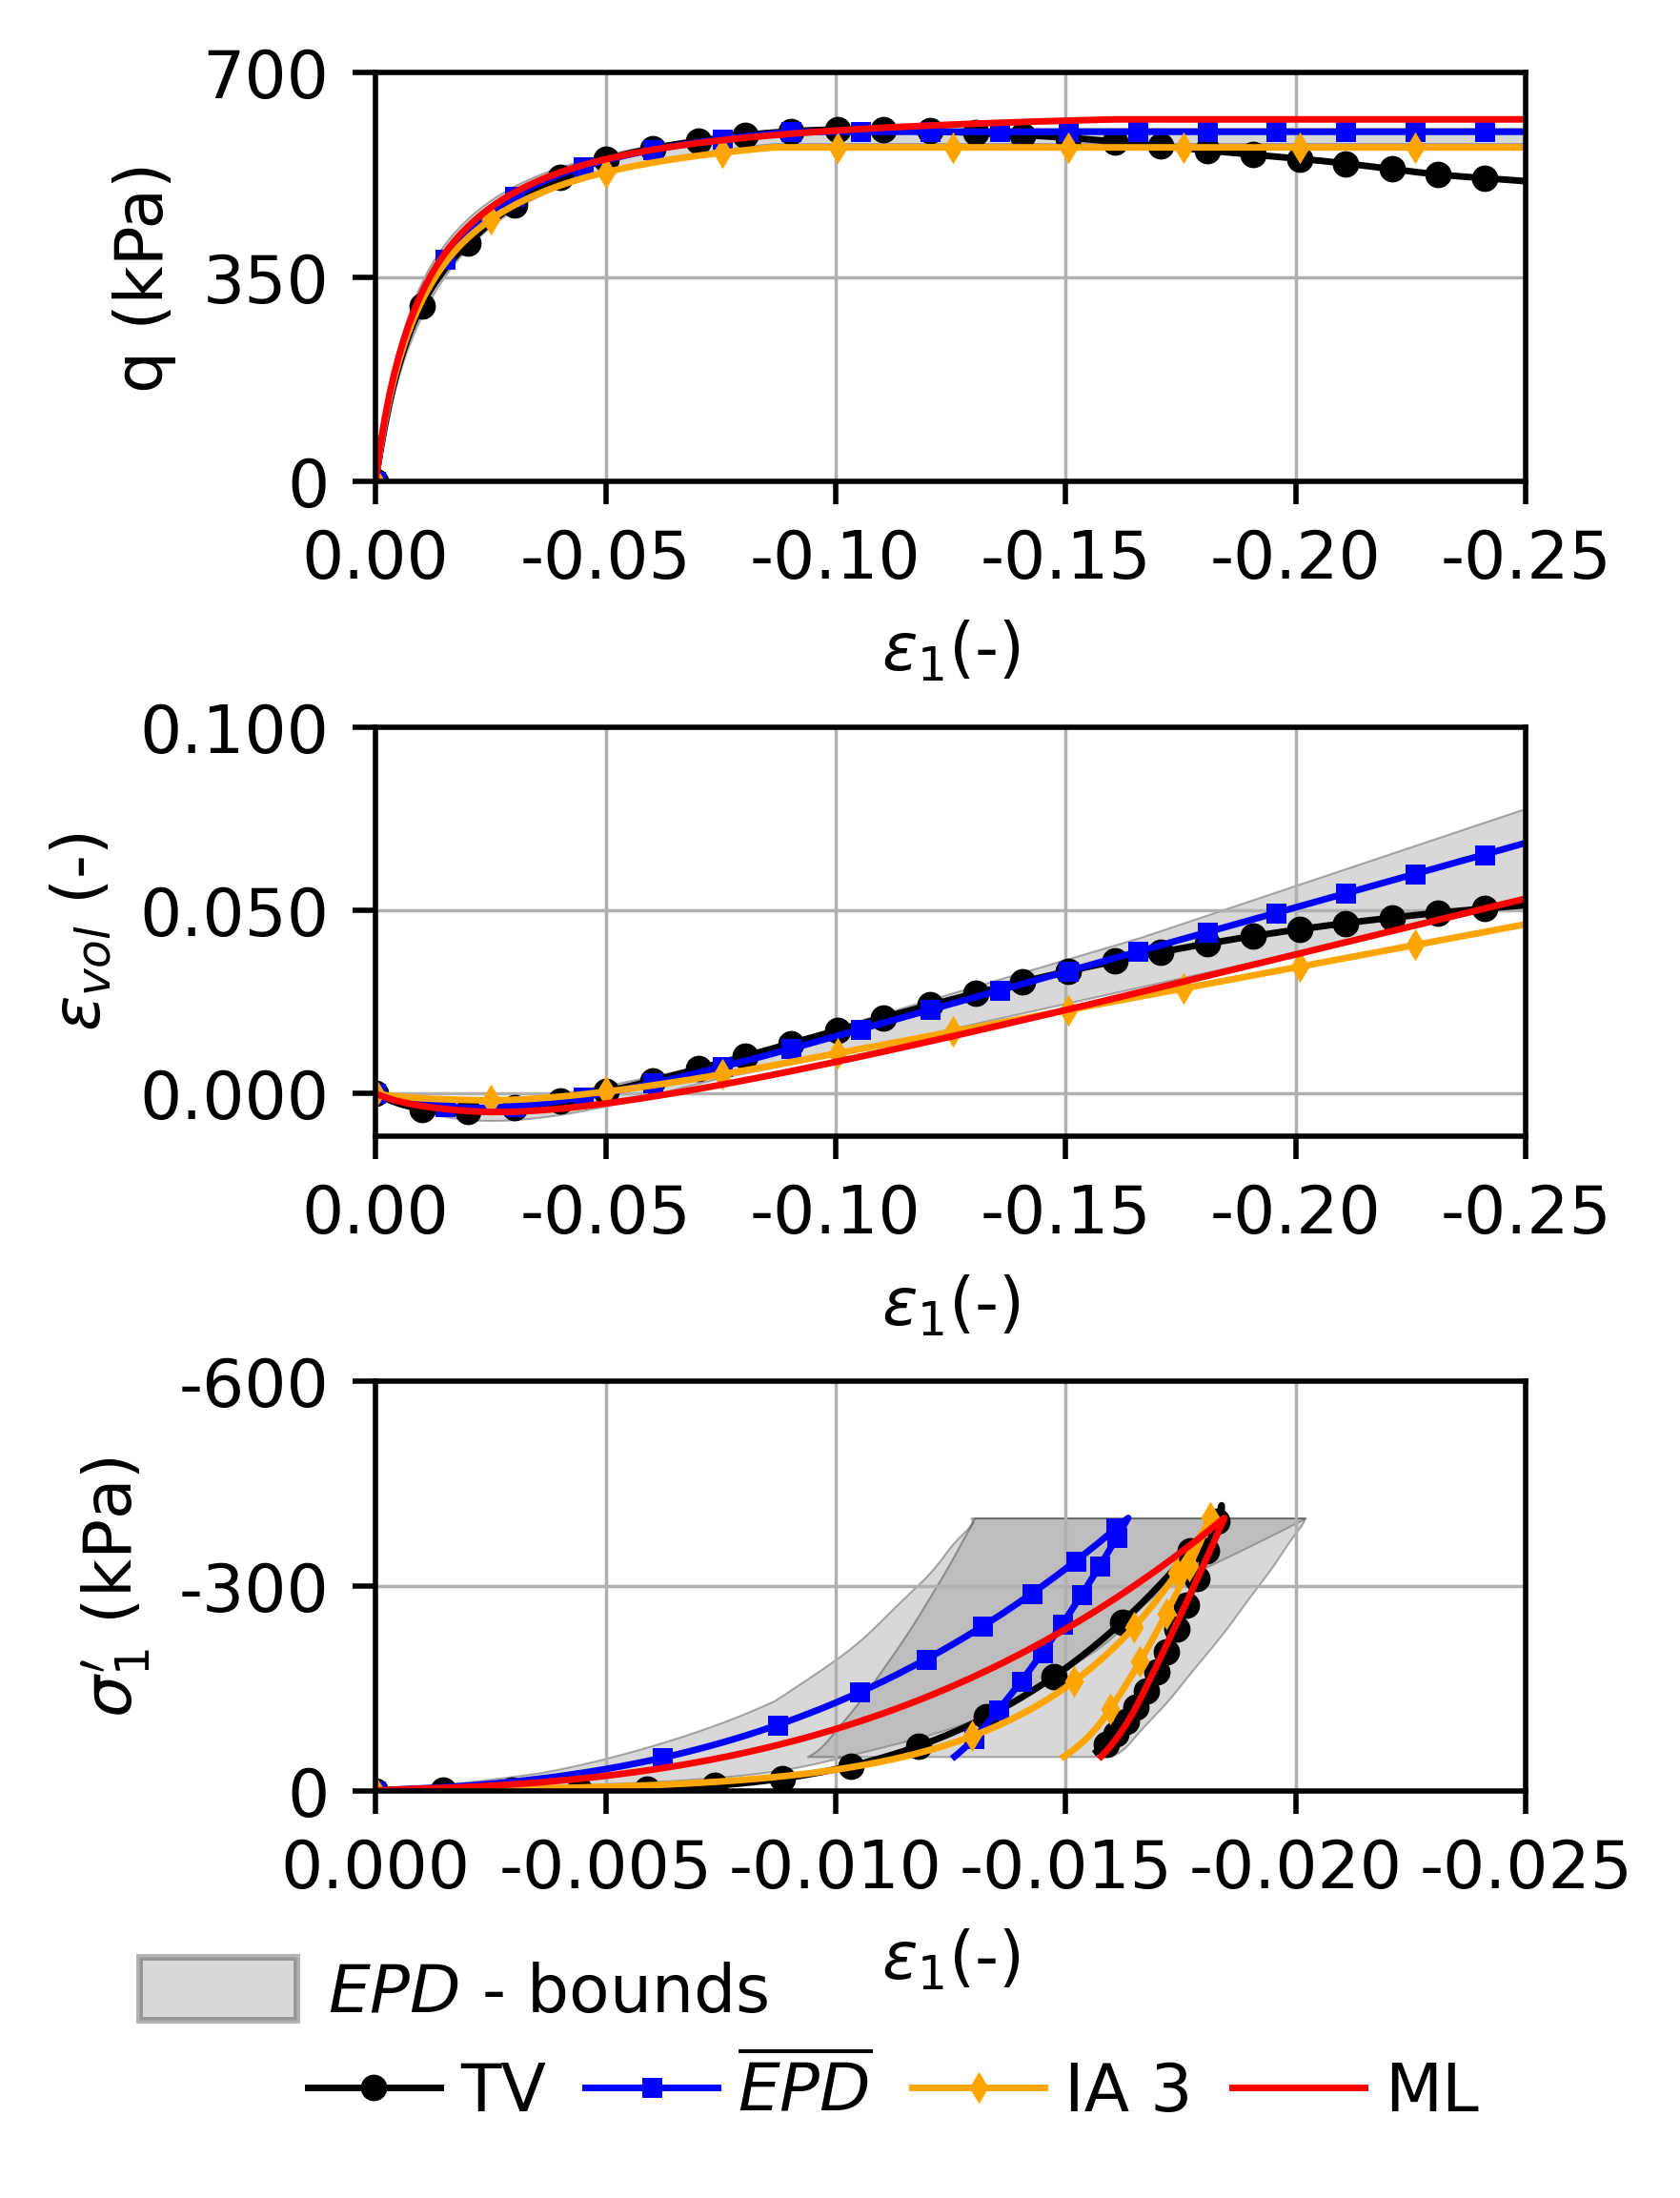

In [159]:
folders = ['02_rawdata_interpolated\\', '12_EPD\\', '13_IA3_final\\', '10_MachineLearning\\', '4_Pred4\\', '5_Pred5\\', '1_Pred1\\', '2_Pred2\\', '3_Pred3\\', '6_Pred6\\']
labels = ['TV', '$\\overline{EPD}$', 'IA 3', 'ML', 'P4', 'P5', 'P1', 'P2', 'P3', 'P6']
main_labels = ['TV', '$\\overline{EPD}$', 'IA 3', 'ML']
main_indices = [0, 1, 2, 3]  # Indices of TV, EPD, ML

del file_names[2]  

for k, example in enumerate(examples):
    fig, axs = plt.subplots(3, 1, figsize=(8.4 * cm, 11.1 * cm), dpi=500)  

    # Storage for uncertainty bounds
    x_all = [[] for _ in range(3)]
    y_all = [[] for _ in range(3)]

    for i, folder in enumerate(folders):
        for j, file_name in enumerate(file_names):
            df_data_syn = pd.read_csv(path_user + example + "\\" + folder + file_name, sep="\t", header=None)

            x = np.array(df_data_syn.iloc[:, 0])
            y = np.array(df_data_syn.iloc[:, 1])

            if i in main_indices:  # Plot TV, EPD, ML
                if j == 2:
                    if i > 2:
                        axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize = 0)
                    else:
                        axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i]*3)
                else:
                    if i > 2:
                        axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize = 0)
                    else:
                        axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i])
            else:  # Store data for uncertainty bounds
                x_all[j].append(x)
                y_all[j].append(y)

            axs[j].grid(True, linewidth=0.5)
            axs[j].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

            axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[-1].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            axs[1].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

            # Invert x-axis for all plots
            axs[j].invert_xaxis()
            axs[j].set_xlabel('$\epsilon_{1}$(-)')
            axs[0].set_ylabel('q (kPa)')
            axs[1].set_ylabel('$\epsilon_{vol}$ (-)')
            axs[-1].set_ylabel("$\sigma_{1}'$ (kPa)")
    


    # Assuming y_all[2] corresponds to the last subplot with loading and unloading cycles
    for j in range(3):  
        if y_all[j]:  # Check if the list is not empty
            if j == 2:  # For the last subplot (loading/unloading cycles)

                x_all_plot = []
                y_all_plot = []

                x_all_plot_unload = []
                y_all_plot_unload = []

                for sig, eps in zip(y_all[j], x_all[j]):
                    min_index = np.argmin(sig)
                    degree = 10

                    # Loading
                    eps1_section_1 = eps[:374].reshape(-1,1)
                    sig1_section_1 = sig[:374].reshape(-1,1)

                    # Unloading
                    eps1_section_2 = eps[375:].reshape(-1,1)
                    sig1_section_2 = sig[375:].reshape(-1,1)
                    
                    sig1_section_1_syn = np.linspace(0, -400, num=375).reshape(-1,1)
                    sig1_section_2_syn = np.linspace(-400, -50, num=375).reshape(-1,1)

                    # Degree of the polynomial
                    degree = 10  # Higher degree with regularization

                    # Polynomial features without intercept
                    poly_features1 = PolynomialFeatures(degree=degree, include_bias=False)
                    poly_features2 = PolynomialFeatures(degree=degree, include_bias=False)
                    X_poly = poly_features1.fit_transform(sig1_section_1)
                    X_poly_unload = poly_features2.fit_transform(sig1_section_2)

                    # Fit model with Ridge regularization
                    ridge_model = Ridge(alpha=0.1, fit_intercept=False, solver = 'auto') 
                    ridge_model.fit(X_poly, eps1_section_1)
                    X_new_poly = poly_features1.transform(sig1_section_1_syn)

                    ridge_model_unload = Ridge(alpha=0.1, fit_intercept=False, solver = 'auto') 
                    ridge_model_unload.fit(X_poly_unload, eps1_section_2)
                    X_new_poly2 = poly_features2.transform(sig1_section_2_syn)

                    # Predict strain values
                    eps1_pred_section_1 = ridge_model.predict(X_new_poly)
                    eps1_pred_section_2 = ridge_model_unload.predict(X_new_poly2)

                    x_all_plot.append(eps1_pred_section_1)
                    y_all_plot.append(sig1_section_1_syn)

                    x_all_plot_unload.append(eps1_pred_section_2)
                    y_all_plot_unload.append(sig1_section_2_syn)

                x_all_array_2d = np.column_stack(x_all_plot)  # Ensures a 2D shape (num_points, 6)
                x_all_array_2d_unload = np.column_stack(x_all_plot_unload)  # Ensures a 2D shape (num_points, 6)
                
                # Calculate upper and lower bounds for loading phase
                x_min = np.min(x_all_array_2d, axis=1)  # Min across all 6 simulations for each point
                x_max = np.max(x_all_array_2d, axis=1)  # Max across all 6 simulations for each point

                x_min_unload = np.min(x_all_array_2d_unload, axis=1)  # Min across all 6 simulations for each point
                x_max_unload = np.max(x_all_array_2d_unload, axis=1)  # Max across all 6 simulations for each point

                sig1_section_1_syn = np.linspace(0, -400, num=375)
                sig1_section_2_syn = np.linspace(-400, -50, num=375)
                
                axs[j].fill_betweenx(sig1_section_1_syn, x_min, x_max, color='grey', alpha=0.3, lw=0.3, ec = 'black')  # Loading bounds
                axs[j].fill_betweenx(sig1_section_2_syn, x_min_unload, x_max_unload, color='grey', alpha=0.3, lw=0.3, ec = 'black')  # Unloading bounds

            else:
                # For other subplots (normal upper/lower bounds)
                y_lower = np.min(y_all[j], axis=0)
                y_upper = np.max(y_all[j], axis=0)
                axs[j].fill_between(x_all[j][0], y_lower, y_upper, color='grey', alpha=0.3, lw=0.3, ec = 'black')  # Shaded region for normal subplots
        else:
            print(f"Warning: No data for uncertainty bounds in subplot {j}")
        
        if j == 20:  # stress path
            default_ticks = axs[1].get_xticks()
            axs[2].set_yticks([0, 600, 1200])
            axs[2].set_ylim(0)
            axs[2].set_xlim(xmin=0, xmax=-1000)
            axs[2].set_xlabel("p' (kPa)")
            axs[2].set_ylabel('q (kPa)')
        if j == 0:  # stress strain
            axs[0].set_xlim(0, -0.25)
            # axs[0].set_yticks([0, 600, 1200])
            axs[0].set_yticks([0, 350, 700])
            axs[0].set_ylim(0)
        if j == 1:  # volumetric behaviour
            axs[1].set_yticks([0, 0.05,0.10])
            axs[1].set_xlim(0, -0.25)
        if j == 2:  # oedoemeter
            axs[2].set_ylim(-600, 0)
            axs[2].set_yticks([0, -300, -600])
            axs[2].set_xlim(-0.025, 0)
            axs[2].invert_yaxis()
            axs[2].invert_xaxis()

    plt.legend(loc='upper center', bbox_to_anchor=(0.45, -0.5), frameon=False, ncol=4, handletextpad=0.3, columnspacing=0.6,)

    # Create an axis outside the main plot (adjust position to place it outside the plot area)
    text_ax = fig.add_axes([0.5, 0.00, 0.4, 0.4])  # Adjust the position and size as needed

    texts = ["$EPD$ - bounds",]
    y = 0.1
    x = -0.5
    colors = ['k', 'orange']
    alphas = [1,1,1,1]

    # Loop for text and rectangle
    for text, color, alpha in zip(texts, colors, alphas):
        # text_ax.text(x+0.27, 0.05 + y, text, transform=text_ax.transAxes, va='center', ha='left', color=color, alpha=alpha)
        # rect = Rectangle((x, 0.02 + y), 0.25, 0.08, transform=text_ax.transAxes, linewidth=1, edgecolor='black', facecolor='grey', alpha=0.3)
        # text_ax.add_patch(rect)
        # y = y - 0.2

        rect = Rectangle((0.05, 0.05), 0.10, 0.03,
                 transform=fig.transFigure,  # place in figure coords
                 facecolor='grey', edgecolor='black', alpha=0.3)
        fig.patches.append(rect)

        fig.text(0.17, 0.063, "$EPD$ - bounds", va='center', ha='left')


    # Hide the axis for the new text_ax
    text_ax.axis('off')
    
    plt.subplots_adjust(left=0.20, right=0.93, bottom=0.16, top=0.985, wspace=0.40, hspace=0.6)
    plt.savefig(r"../graphics/" + "RealData" + f"{example}" + ".png", dpi=1000)

c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.10001e-51): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.87227e-53): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.99586e-51): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\linear_model\_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.82198e-53): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=

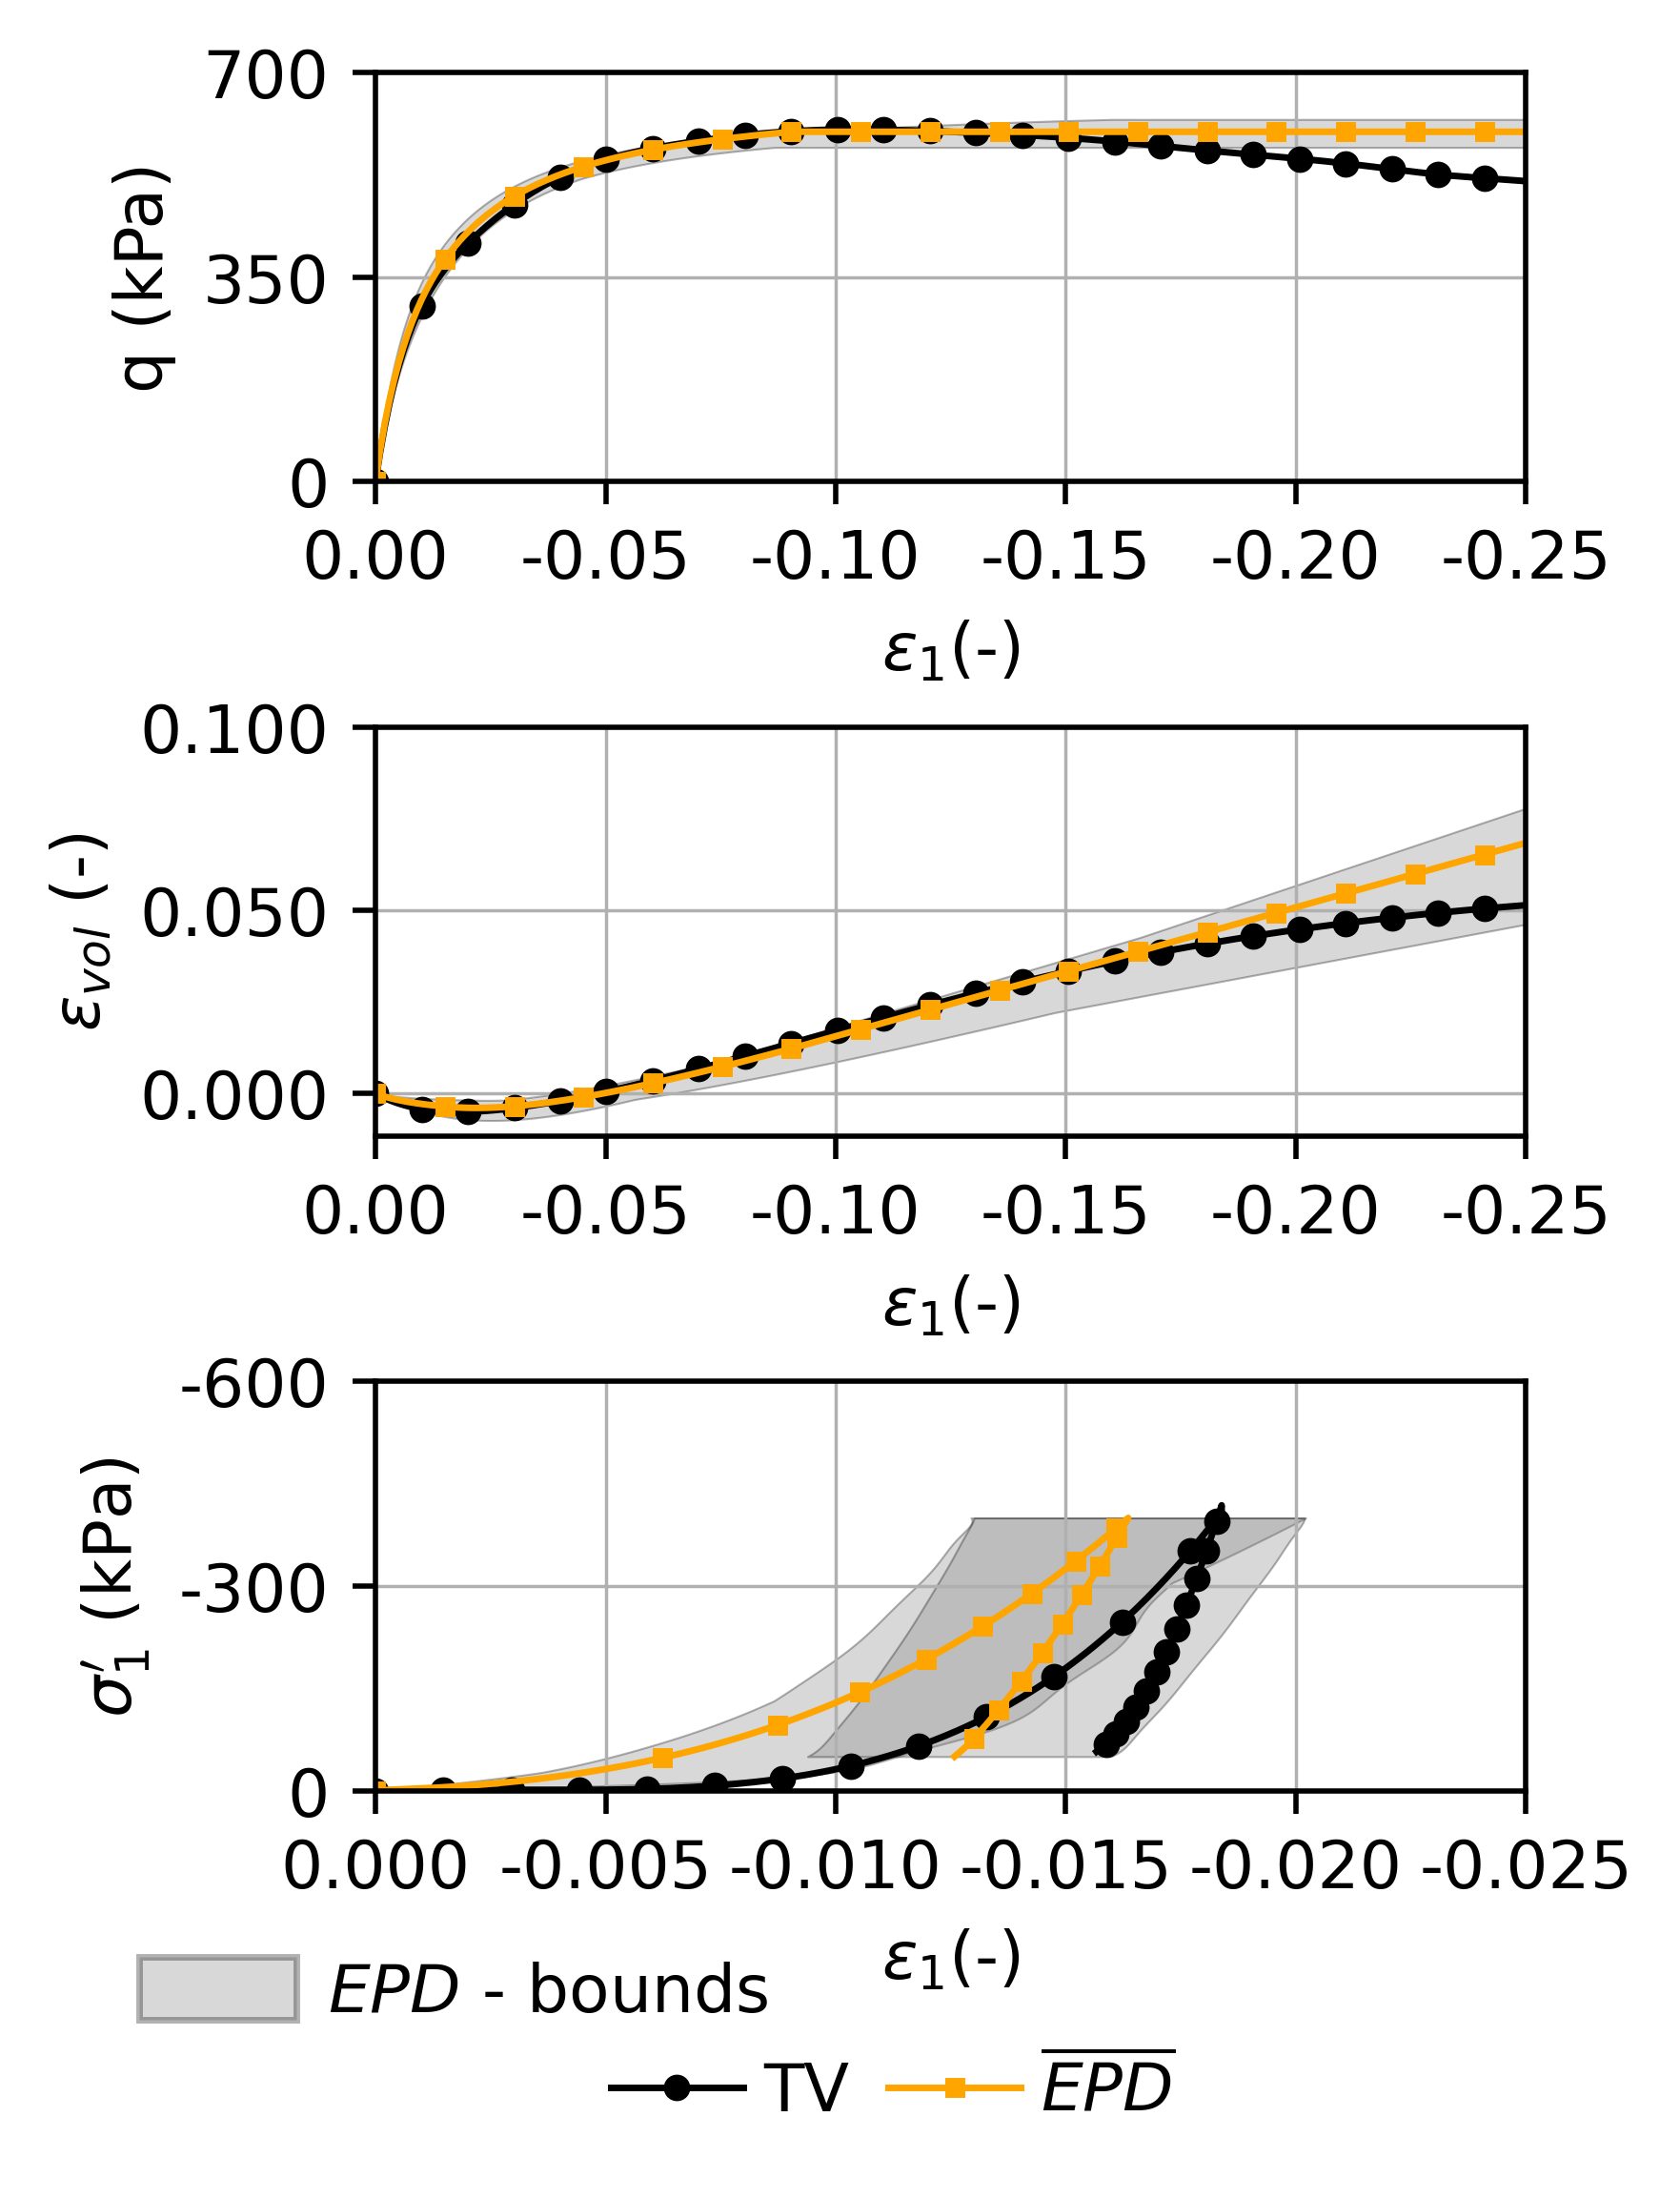

In [ ]:
folders = ['02_rawdata_interpolated\\', '12_EPD\\', '13_IA3_final\\', '10_MachineLearning\\', '4_Pred4\\', '5_Pred5\\', '1_Pred1\\', '2_Pred2\\', '3_Pred3\\', '6_Pred6\\']
labels = ['TV', '$\\overline{EPD}$', 'IA 3', 'ML', 'P4', 'P5', 'P1', 'P2', 'P3', 'P6']
main_labels = ['TV', '$\\overline{EPD}$', 'IA 3', 'ML']
main_indices = [0, 1, 2, 3]  # Indices of TV, EPD, ML
main_indices = [0, 1]  # Indices of TV, EPD, ML

# del file_names[2]  

colors = ['k', 'b', 'orange', 'red', 'orange', 'green', 'black', 'yellow', 'pink', 'brown', 'cyan', 'magenta']
i = 0

for k, example in enumerate(examples):
    fig, axs = plt.subplots(3, 1, figsize=(8.4 * cm, 11.1 * cm), dpi=500)  

    # Storage for uncertainty bounds
    x_all = [[] for _ in range(3)]
    y_all = [[] for _ in range(3)]

    for i, folder in enumerate(folders):
        for j, file_name in enumerate(file_names):
            df_data_syn = pd.read_csv(path_user + example + "\\" + folder + file_name, sep="\t", header=None)

            x = np.array(df_data_syn.iloc[:, 0])
            y = np.array(df_data_syn.iloc[:, 1])

            if i in main_indices:  # Plot TV, EPD, ML
                if j == 2:
                    if i > 2:
                        axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize = 0)
                    else:
                        axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i]*3)
                else:
                    if i > 2:
                        axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize = 0)
                    else:
                        axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i])
            else:  # Store data for uncertainty bounds
                x_all[j].append(x)
                y_all[j].append(y)

            axs[j].grid(True, linewidth=0.5)
            axs[j].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

            axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[-1].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            axs[1].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

            # Invert x-axis for all plots
            axs[j].invert_xaxis()
            axs[j].set_xlabel('$\epsilon_{1}$(-)')
            axs[0].set_ylabel('q (kPa)')
            axs[1].set_ylabel('$\epsilon_{vol}$ (-)')
            axs[-1].set_ylabel("$\sigma_{1}'$ (kPa)")
    


    # Assuming y_all[2] corresponds to the last subplot with loading and unloading cycles
    for j in range(3):  
        if y_all[j]:  # Check if the list is not empty
            if j == 2:  # For the last subplot (loading/unloading cycles)

                x_all_plot = []
                y_all_plot = []

                x_all_plot_unload = []
                y_all_plot_unload = []

                for sig, eps in zip(y_all[j], x_all[j]):
                    min_index = np.argmin(sig)
                    degree = 10

                    # Loading
                    eps1_section_1 = eps[:374].reshape(-1,1)
                    sig1_section_1 = sig[:374].reshape(-1,1)

                    # Unloading
                    eps1_section_2 = eps[375:].reshape(-1,1)
                    sig1_section_2 = sig[375:].reshape(-1,1)
                    
                    sig1_section_1_syn = np.linspace(0, -400, num=375).reshape(-1,1)
                    sig1_section_2_syn = np.linspace(-400, -50, num=375).reshape(-1,1)

                    # Degree of the polynomial
                    degree = 10  # Higher degree with regularization

                    # Polynomial features without intercept
                    poly_features1 = PolynomialFeatures(degree=degree, include_bias=False)
                    poly_features2 = PolynomialFeatures(degree=degree, include_bias=False)
                    X_poly = poly_features1.fit_transform(sig1_section_1)
                    X_poly_unload = poly_features2.fit_transform(sig1_section_2)

                    # Fit model with Ridge regularization
                    ridge_model = Ridge(alpha=0.1, fit_intercept=False, solver = 'auto') 
                    ridge_model.fit(X_poly, eps1_section_1)
                    X_new_poly = poly_features1.transform(sig1_section_1_syn)

                    ridge_model_unload = Ridge(alpha=0.1, fit_intercept=False, solver = 'auto') 
                    ridge_model_unload.fit(X_poly_unload, eps1_section_2)
                    X_new_poly2 = poly_features2.transform(sig1_section_2_syn)

                    # Predict strain values
                    eps1_pred_section_1 = ridge_model.predict(X_new_poly)
                    eps1_pred_section_2 = ridge_model_unload.predict(X_new_poly2)

                    x_all_plot.append(eps1_pred_section_1)
                    y_all_plot.append(sig1_section_1_syn)

                    x_all_plot_unload.append(eps1_pred_section_2)
                    y_all_plot_unload.append(sig1_section_2_syn)

                x_all_array_2d = np.column_stack(x_all_plot)  # Ensures a 2D shape (num_points, 6)
                x_all_array_2d_unload = np.column_stack(x_all_plot_unload)  # Ensures a 2D shape (num_points, 6)
                
                # Calculate upper and lower bounds for loading phase
                x_min = np.min(x_all_array_2d, axis=1)  # Min across all 6 simulations for each point
                x_max = np.max(x_all_array_2d, axis=1)  # Max across all 6 simulations for each point

                x_min_unload = np.min(x_all_array_2d_unload, axis=1)  # Min across all 6 simulations for each point
                x_max_unload = np.max(x_all_array_2d_unload, axis=1)  # Max across all 6 simulations for each point

                sig1_section_1_syn = np.linspace(0, -400, num=375)
                sig1_section_2_syn = np.linspace(-400, -50, num=375)
                
                axs[j].fill_betweenx(sig1_section_1_syn, x_min, x_max, color='grey', alpha=0.3, lw=0.3, ec = 'black')  # Loading bounds
                axs[j].fill_betweenx(sig1_section_2_syn, x_min_unload, x_max_unload, color='grey', alpha=0.3, lw=0.3, ec = 'black')  # Unloading bounds

            else:
                # For other subplots (normal upper/lower bounds)
                y_lower = np.min(y_all[j], axis=0)
                y_upper = np.max(y_all[j], axis=0)
                axs[j].fill_between(x_all[j][0], y_lower, y_upper, color='grey', alpha=0.3, lw=0.3, ec = 'black')  # Shaded region for normal subplots
        else:
            print(f"Warning: No data for uncertainty bounds in subplot {j}")
        
        if j == 20:  # stress path
            default_ticks = axs[1].get_xticks()
            axs[2].set_yticks([0, 600, 1200])
            axs[2].set_ylim(0)
            axs[2].set_xlim(xmin=0, xmax=-1000)
            axs[2].set_xlabel("p' (kPa)")
            axs[2].set_ylabel('q (kPa)')
        if j == 0:  # stress strain
            axs[0].set_xlim(0, -0.25)
            # axs[0].set_yticks([0, 600, 1200])
            axs[0].set_yticks([0, 350, 700])
            axs[0].set_ylim(0)
        if j == 1:  # volumetric behaviour
            axs[1].set_yticks([0, 0.05,0.10])
            axs[1].set_xlim(0, -0.25)
        if j == 2:  # oedoemeter
            axs[2].set_ylim(-600, 0)
            axs[2].set_yticks([0, -300, -600])
            axs[2].set_xlim(-0.025, 0)
            axs[2].invert_yaxis()
            axs[2].invert_xaxis()

    plt.legend(loc='upper center', bbox_to_anchor=(0.45, -0.5), frameon=False, ncol=4, handletextpad=0.3, columnspacing=0.6,)

    # Create an axis outside the main plot (adjust position to place it outside the plot area)
    text_ax = fig.add_axes([0.5, 0.00, 0.4, 0.4])  # Adjust the position and size as needed

    texts = ["$EPD$ - bounds",]
    y = 0.1
    x = -0.5
    colors = ['k', 'b', 'orange', 'red']
    alphas = [1,1,1,1]

    # Loop for text and rectangle
    for text, color, alpha in zip(texts, colors, alphas):
        # text_ax.text(x+0.27, 0.05 + y, text, transform=text_ax.transAxes, va='center', ha='left', color=color, alpha=alpha)
        # rect = Rectangle((x, 0.02 + y), 0.25, 0.08, transform=text_ax.transAxes, linewidth=1, edgecolor='black', facecolor='grey', alpha=0.3)
        # text_ax.add_patch(rect)
        # y = y - 0.2

        rect = Rectangle((0.05, 0.05), 0.10, 0.03,
                 transform=fig.transFigure,  # place in figure coords
                 facecolor='grey', edgecolor='black', alpha=0.3)
        fig.patches.append(rect)

        fig.text(0.17, 0.063, "$EPD$ - bounds", va='center', ha='left')


    # Hide the axis for the new text_ax
    text_ax.axis('off')
    
    plt.subplots_adjust(left=0.20, right=0.93, bottom=0.16, top=0.985, wspace=0.40, hspace=0.6)
    plt.savefig(r"../graphics/" + "RealData" + f"{example}" + "_2.png", dpi=1000)